# Sleep-EDF 01 — Data exploration (one recording pair)

**Phase 2 of the thesis: replicating the ECG200 faithfulness study on a second, very different dataset —
Sleep-EDF (EEG sleep recordings).** This is the *first* look at the data, mirroring the spirit of the
ECG200 notebook 01: understand what the data physically is before any modelling.

> **Scope: read and report only.** This notebook inspects **one recording pair** in detail and explains
> what it finds. It does **no** preprocessing, no epoching, no label conversion, and makes no decisions.
> (The full dataset is ~8 GB across ~200 recordings — we deliberately look at *one* first.)

## What is Sleep-EDF?

Sleep-EDF is a public dataset of overnight **polysomnography (PSG)** recordings with expert **sleep-stage
annotations**. Two things are recorded:

- **The PSG signals** — a set of physiological time-series recorded through the night: brain activity
  (**EEG**, electroencephalogram), eye movements (**EOG**), muscle tone (**EMG**), plus respiration and
  temperature. These are the *inputs*.
- **The hypnogram** — a sleep expert's labelling of the night into **sleep stages**, one label per fixed
  time window. This is the *target*.

**Sleep staging** is the task of classifying each short window of the night into a sleep stage. Sleep is
not uniform: it cycles through distinct stages with characteristic brain-wave patterns. The modern
(AASM) scheme uses **5 classes**: **W** (awake), **N1** (light sleep / drowsy), **N2** (deeper, with
distinctive "spindle" and "K-complex" waveforms), **N3** (deep / slow-wave sleep), and **REM** (rapid-eye-
movement / dreaming sleep). Classifying a signal window into one of these 5 stages is the classification
task — the analogue of ECG200's "normal vs abnormal beat", but **5-class** and on a very different signal.

## 1. Locate the files

The raw data lives in `data/sleep_edf/raw/`. Let's see its structure without loading any signals.

In [1]:
from pathlib import Path
import glob, os

# Find the repo root robustly (this notebook sits two levels down, in notebooks/sleep_edf/).
ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "sleep_edf" / "raw").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data" / "sleep_edf" / "raw"
FIG_DIR = ROOT / "results" / "sleep_edf" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

print("raw/ top level:", sorted(p.name for p in RAW.iterdir()))
for sub in ["sleep-cassette", "sleep-telemetry"]:
    d = RAW / sub
    if d.exists():
        n_psg = len(glob.glob(str(d / "*PSG.edf")))
        n_hyp = len(glob.glob(str(d / "*Hypnogram.edf")))
        subjects = {os.path.basename(p)[3:5] for p in glob.glob(str(d / "*PSG.edf"))}
        print(f"  {sub}: {n_psg} PSG + {n_hyp} hypnogram files, ~{len(subjects)} subjects")

raw/ top level: ['RECORDS', 'RECORDS-v1', 'SC-subjects.xls', 'SHA256SUMS.txt', 'ST-subjects.xls', 'sleep-cassette', 'sleep-telemetry']
  sleep-cassette: 153 PSG + 153 hypnogram files, ~78 subjects
  sleep-telemetry: 44 PSG + 44 hypnogram files, ~22 subjects


### What we're looking at

There are **two subsets**:

- **Sleep Cassette (SC)** — healthy subjects recorded at home over ~2 nights each (the larger subset).
- **Sleep Telemetry (ST)** — a smaller study (subjects given a sleep medication vs. placebo).

**File-naming convention:** each recording is `SC4ssNxx-PSG.edf` (the signals) paired with
`SC4ssNxx-Hypnogram.edf` (the labels), where `ss` = subject number and `N` = night. The PSG and its
hypnogram **share the first 6 characters** (e.g. `SC4001…`), which is how a signal file is matched to its
annotation file. Every PSG file has exactly one hypnogram partner (equal counts above confirm this).

We will use the **Sleep Cassette** subset and inspect a single pair. **We do not load all recordings** —
that's the ~8 GB we're deliberately avoiding at this stage.

In [2]:
# Pick ONE recording and find its hypnogram partner by the shared 6-char prefix.
psg_path = RAW / "sleep-cassette" / "SC4001E0-PSG.edf"
prefix = psg_path.name[:6]                      # 'SC4001' = subject+night key
hyp_path = next(RAW.glob(f"sleep-cassette/{prefix}*-Hypnogram.edf"))
print("PSG       :", psg_path.name)
print("hypnogram :", hyp_path.name, f"(matched on prefix {prefix!r})")

PSG       : SC4001E0-PSG.edf
hypnogram : SC4001EC-Hypnogram.edf (matched on prefix 'SC4001')


## 2. The PSG signals — what was recorded

We load **one** PSG file and inspect its header (channels, sampling rates, duration). We are only reading
metadata and, below, a tiny slice — not the whole ~22-hour recording into memory.

**Some EEG background for reading the output:**
- **EEG (electroencephalogram)** measures the brain's electrical activity via electrodes on the scalp.
  Channels are named by the electrode *pair* they measure the voltage difference between — e.g.
  **`EEG Fpz-Cz`** is the voltage between the forehead (Fpz) and the top-centre of the head (Cz). Different
  pairs "see" different regions/wave patterns.
- **EOG (electro-oculogram)** tracks **eye movements** (crucial for spotting REM sleep).
- **EMG (electromyogram)** tracks **muscle tone** (drops during REM).
- **Respiration** and **temperature** are slow body signals.
- **Sampling frequency** = how many samples per second a channel was digitised at. Higher = finer time
  detail. EEG needs a high rate to capture fast brain waves; body signals like temperature change slowly
  and are sampled much more coarsely — so **channels can have different native sampling rates**.

In [3]:
import mne, warnings
warnings.filterwarnings("ignore"); mne.set_log_level("ERROR")

raw = mne.io.read_raw_edf(psg_path, preload=False)   # header only, no signals in memory
print(f"number of channels: {len(raw.ch_names)}")
print(f"total duration    : {raw.times[-1]:.0f} s  =  {raw.times[-1]/3600:.1f} hours")
print()

# Native per-channel sampling rate straight from the EDF header (MNE resamples to a common rate).
with open(psg_path, "rb") as f:
    h = f.read(256); rec_dur = float(h[244:252]); ns = int(h[252:256])
    labels = [f.read(16).decode("latin-1").strip() for _ in range(ns)]
    f.read(ns * (80+8+8+8+8+8+80)); nsamp = [int(f.read(8)) for _ in range(ns)]

meaning = {"EEG Fpz-Cz":"brain activity (frontal–central)", "EEG Pz-Oz":"brain activity (parietal–occipital)",
           "EOG horizontal":"eye movements", "EMG submental":"chin muscle tone",
           "Resp oro-nasal":"breathing (airflow)", "Temp rectal":"body temperature", "Event marker":"event markers"}
print(f"{'channel':18s} {'native rate':>11s}   what it is")
for lab, n in zip(labels, nsamp):
    print(f"  {lab:18s} {n/rec_dur:>7.0f} Hz   {meaning.get(lab, '?')}")

number of channels: 7
total duration    : 79500 s  =  22.1 hours

channel            native rate   what it is
  EEG Fpz-Cz             100 Hz   brain activity (frontal–central)
  EEG Pz-Oz              100 Hz   brain activity (parietal–occipital)
  EOG horizontal         100 Hz   eye movements
  Resp oro-nasal           1 Hz   breathing (airflow)
  EMG submental            1 Hz   chin muscle tone
  Temp rectal              1 Hz   body temperature
  Event marker             1 Hz   event markers


### What this tells us

This recording has **7 channels**: two **EEG** channels (`Fpz-Cz`, `Pz-Oz`) and one **EOG**, all sampled
at **100 Hz** (100 samples/second — enough to capture sleep brain-waves), plus **EMG**, **respiration**,
**temperature**, and an **event marker**, all sampled at just **1 Hz** (slow body signals). So the signal
that matters most for sleep staging — the **EEG at 100 Hz** — is only part of what's stored.

The recording is **~22 hours** long. That's far longer than a night's sleep because the Sleep-Cassette
subjects wore the recorder through a whole day–night at home, so most of the recording is **daytime wake**
before and after the actual sleep. (We'll see this directly in the hypnogram next.)

## 3. The hypnogram — how the sleep stages are stored

Now the matching hypnogram. The sleep-stage labels are stored as **annotations**: not one label per sample,
but a list of **time-spans**, each with an **onset** (when it starts, in seconds), a **duration** (how long
it lasts), and a **description** (the stage). Consecutive windows of the same stage are merged into one span.

In [4]:
import collections
ann = mne.read_annotations(hyp_path)
print(f"number of annotation spans: {len(ann)}")
print(f"stage labels present (span counts): {dict(collections.Counter(ann.description))}")
print()
print("first 6 annotation spans (onset, duration, stage):")
for i in range(6):
    print(f"  onset={ann.onset[i]:>7.0f}s   duration={ann.duration[i]:>6.0f}s   {ann.description[i]}")
print()
print(f"all durations are multiples of 30 s: {all((d % 30)==0 for d in ann.duration)}")
print(f"total annotated span: {ann.onset[-1]+ann.duration[-1]:.0f} s = {(ann.onset[-1]+ann.duration[-1])/3600:.0f} h")

number of annotation spans: 154
stage labels present (span counts): {np.str_('Sleep stage W'): 12, np.str_('Sleep stage 1'): 24, np.str_('Sleep stage 2'): 40, np.str_('Sleep stage 3'): 48, np.str_('Sleep stage 4'): 23, np.str_('Sleep stage R'): 6, np.str_('Sleep stage ?'): 1}

first 6 annotation spans (onset, duration, stage):
  onset=      0s   duration= 30630s   Sleep stage W
  onset=  30630s   duration=   120s   Sleep stage 1
  onset=  30750s   duration=   390s   Sleep stage 2
  onset=  31140s   duration=    30s   Sleep stage 3
  onset=  31170s   duration=    30s   Sleep stage 2
  onset=  31200s   duration=   150s   Sleep stage 3

all durations are multiples of 30 s: True
total annotated span: 86400 s = 24 h


### How to read the annotations

- The labels use the **older Rechtschaffen & Kales scheme**: `Sleep stage W, 1, 2, 3, 4, R, ?`. Note there
  are **stages 3 *and* 4** here (deep sleep was split into two). The modern **5-class AASM** scheme merges
  **3 + 4 → N3**, giving W / N1 / N2 / N3 / REM. `?` marks unscored/unknown windows. *(How to map R&K → the
  5 AASM classes is a decision for later, not now.)*
- Every duration is a **multiple of 30 seconds**. **30 s is the standard "epoch"** — the fixed window sleep
  experts score one stage at a time. A span of `duration=390s` is simply 13 consecutive 30-s epochs all
  scored the same stage, merged into one annotation.
- The annotations mark **time-spans over the signal**, *not* a label on every sample. To get a label for a
  specific moment, you find which span's `[onset, onset+duration)` interval contains that time. **We are
  not converting these to per-epoch labels here** — just showing the raw structure.
- The very first span is **`Sleep stage W` for ~8.5 hours** — that's the long daytime-wake period before the
  subject went to sleep, exactly matching the over-long recording we saw above. This (huge wake dominance)
  is a class-balance issue we'll have to think about later.

## 4. Visual sanity check — what does 30 seconds of EEG look like?

Finally, we plot a single **30-second epoch** of one EEG channel, taken from a known sleep stage, so we can
*see* the raw signal. (30 s because that's one scoring epoch.) We pick a window that falls entirely inside
one stage and label it.

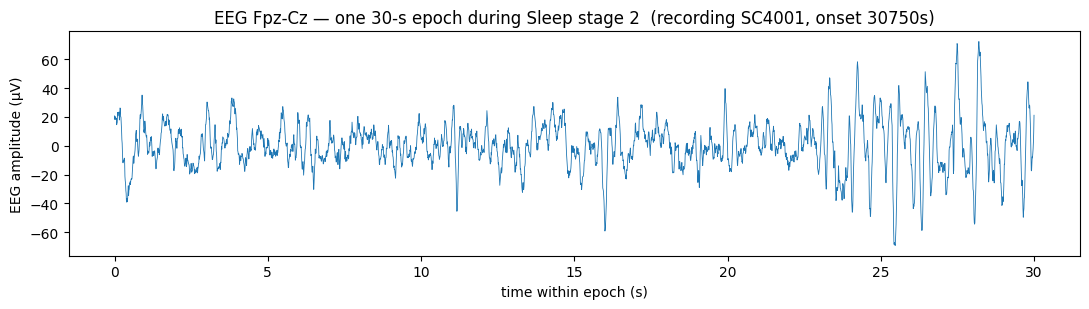

plotted EEG Fpz-Cz: 30 s = 3001 samples at 100 Hz, during Sleep stage 2


In [5]:
import numpy as np, matplotlib.pyplot as plt

# Find a 30-s window inside a clear sleep stage (Stage 2 has visible structure).
target = "Sleep stage 2"
idx = next(i for i in range(len(ann)) if ann.description[i] == target and ann.duration[i] >= 30)
t0 = ann.onset[idx]                                  # start of that stage span
ch = "EEG Fpz-Cz"
seg = raw.copy().pick([ch]).crop(tmin=t0, tmax=t0+30).get_data()[0]   # load ONLY this 30-s slice
sf = 100.0
t = np.arange(len(seg)) / sf

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(t, seg * 1e6, lw=0.6, color="C0")            # Volts -> microvolts for readability
ax.set_xlabel("time within epoch (s)"); ax.set_ylabel("EEG amplitude (µV)")
ax.set_title(f"{ch} — one 30-s epoch during {target}  (recording {psg_path.name[:6]}, onset {t0:.0f}s)")
fig.tight_layout(); fig.savefig(FIG_DIR / "sleep_edf_01_eeg_epoch.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"plotted {ch}: 30 s = {len(seg)} samples at {sf:.0f} Hz, during {target}")

### What we're seeing

This is 30 seconds of raw scalp EEG (in microvolts) that a sleep expert scored as **Stage 2 (N2)**. Unlike
the clean, aligned single heartbeat of ECG200, an EEG epoch is a **continuous, noisy oscillation** whose
*character* (dominant frequencies, occasional bursts like spindles/K-complexes) is what distinguishes sleep
stages — a much richer, harder signal than ECG200's short beat.

## Summary — what we now know, and open questions for later

**What this one recording pair tells us about the data's structure:**
- Each recording = a **PSG `.edf`** (7 channels: 2× EEG + EOG at 100 Hz, plus EMG/respiration/temperature/
  event at 1 Hz) paired with a **hypnogram `.edf`** matched by a shared 6-char filename prefix.
- Recordings are **very long (~22 h)**, dominated by **daytime wake**, with the actual sleep a fraction of it.
- Sleep-stage labels are **annotation spans** (onset + duration + stage), on a **30-s epoch** grid, using the
  older **R&K** scheme (W, 1, 2, 3, 4, R, ?), not per-sample labels.
- The signal is **continuous EEG oscillation** — categorically different from ECG200's aligned single beats.
- Two subsets: **Sleep Cassette (~78 subjects, 153 recordings)** and **Sleep Telemetry (~22 subjects, 44)**.

**Open questions — to decide later, not now:**
- **Which subset / how many subjects & recordings** to use (SC only? both? a subset?).
- **Which channel(s)** — one EEG channel (e.g. `Fpz-Cz`, common in the literature) or multi-channel EEG/EOG?
  (The harness now supports multi-channel, but single-channel is simpler and standard for sleep staging.)
- **How to map R&K → the 5 AASM classes** (merge stages 3+4 → N3; handle `?` and Movement).
- **Class balance across the full dataset** — likely heavy **Wake** dominance (and how much to trim the long
  pre/post-sleep wake) — needs measuring across recordings before modelling.
- **Epoching** — the 30-s epoch is the natural sample unit; how to turn annotation spans into per-epoch
  labelled windows.
- **Subject-level splitting** — train/val/test must split by **subject** (never mix a subject's epochs across
  splits) to avoid leakage — different from ECG200's per-sample split.
- The **region-size analysis** (the 01b-equivalent) must be re-run for EEG epochs to choose Sleep-EDF's own
  region sizes (do **not** reuse ECG200's 10%/5%).

*Nothing above is decided here — this notebook only characterised one recording pair.*